# Importation des packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle 
import scipy.stats as st

# Définition des fonctions

### Fonction pour créer un boxplot

In [2]:
def create_boxplot(data, labels, colors, size=(8, 5), limite_echelle=np.arange(0, 1.01, 0.05)):
    plt.figure(figsize=size)

    # Création des boxplots
    boxplot = plt.boxplot(data, patch_artist=True)
    # Ajout des labels des modèles
    plt.xticks(range(1, len(labels) + 1), labels)

    # Application des couleurs des boxplots
    for patch, color in zip(boxplot["boxes"], colors):
        patch.set_facecolor(color) # Intérieur
        patch.set_alpha(0.3)  # Transparence
        patch.set_edgecolor(color)  # Contour

    # Visibilité de la médiane
    for median in boxplot["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)

    # Ajout d'une grille en arrière plan
    plt.grid(True, linestyle="--", alpha=0.6, axis="y")

    # Ajustement de l'échelle
    plt.yticks(limite_echelle)

    # Titre et légende
    plt.title("IoU values on validation sets")

    # Affichage
    plt.show()


### Fonction pour visualiser et comparer deux boxplots côte à côte

In [3]:
def plot_two_boxplots(data1, data2, labels1, labels2, colors, size=(8,5)):
    plt.figure(figsize=size) 

    # ---- Premier graphique ----
    plt.subplot(1,2,1)
    boxplot = plt.boxplot(data1, patch_artist=True) # Création des boxplots
    plt.xticks(range(1, len(labels1) + 1), labels1) # Ajout des labels

    # Application des couleurs des boxplots
    for patch, color in zip(boxplot["boxes"], colors):
        patch.set_facecolor(color) # Intérieur
        patch.set_alpha(0.4)  # Transparence
        patch.set_edgecolor(color)  # Contour

    # Visibilité de la médiane
    for median in boxplot["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)

    plt.grid(True, linestyle="--", alpha=0.6, axis="y") # Ajout d'une grille en arrière plan
    plt.yticks(np.arange(0, 1.01, 0.05)) # Ajustement de l'échelle
    plt.title("IoU values on validation sets") # Titre et légende


    # ---- Deuxième graphique ----
    plt.subplot(1,2,2)
    boxplot = plt.boxplot(data2, patch_artist=True) # Création des boxplots
    plt.xticks(range(1, len(labels2) + 1), labels2) # Ajout des labels

    # Application des couleurs des boxplots
    for patch, color in zip(boxplot["boxes"], colors):
        patch.set_facecolor(color) # Intérieur
        patch.set_alpha(0.4)  # Transparence
        patch.set_edgecolor(color)  # Contour

    # Visibilité de la médiane
    for median in boxplot["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)


    plt.grid(True, linestyle="--", alpha=0.6, axis="y") # Ajout d'une grille en arrière plan
    plt.yticks(np.arange(0, 1.01, 0.05)) # Ajustement de l'échelle
    plt.title("IoU values on validation sets") # Titre et légende

# Visualisation et comparaison des résultats des différents modèles : validation

## Importation des différents modèles

### U-NET models

In [ ]:
# U-Net++ CME EfficientNet
with open('../U-NET/saves/results_cme_unetplusplus_effb5.pkl', 'rb') as f:
    results_UNETplusplus_CME = pickle.load(f)

# U-Net CME
with open('../U-NET/saves/results_cme_unet_resnet34.pkl', 'rb') as f:
    results_UNET_CME = pickle.load(f)

# U-Net
with open('../U-NET/saves/results_unet_resnet34.pkl', 'rb') as f:
    results_UNET = pickle.load(f)

# U-Net sans data augmentation
with open('../U-NET/saves/results_unet_nda_resnet34.pkl', 'rb') as f:
    results_NDA_UNET = pickle.load(f)

# U-Net sans intestin
with open('../U-NET/saves/results_da_unet_resnet34_2.pkl', 'rb') as f:
    results_UNET_no_intestin = pickle.load(f)

# xLSTMU-Net
with open('../U-NET/saves/results_xLSTMUNet.pkl', 'rb') as f:
    results_XLSTM = pickle.load(f)

# CSANET
with open('../U-NET/saves/results_csanet.pkl', 'rb') as f:
    results_CSANET = pickle.load(f)

### YOLO models

In [6]:
# YOLO avec Data Augmentation, loss par défaut
with open('../YOLO26/saves/fold_histories_data_aug_YOLO.pkl', 'rb') as fp:
    results_DA_YOLO = pickle.load(fp)

# YOLO sans Data Augmentation, loss par défaut
with open('../YOLO26/saves/fold_histories_no_data_aug_YOLO.pkl', 'rb') as fp:
    results_NDA_YOLO = pickle.load(fp)

# YOLO avec Data Augmentation, loss modifiée
with open('../YOLO26/saves/fold_histories_data_aug_YOLO_test.pkl', 'rb') as fp:
    results_DA_YOLO_test = pickle.load(fp)

## Comparaisons globales des modèles

### Boxplots des IoU

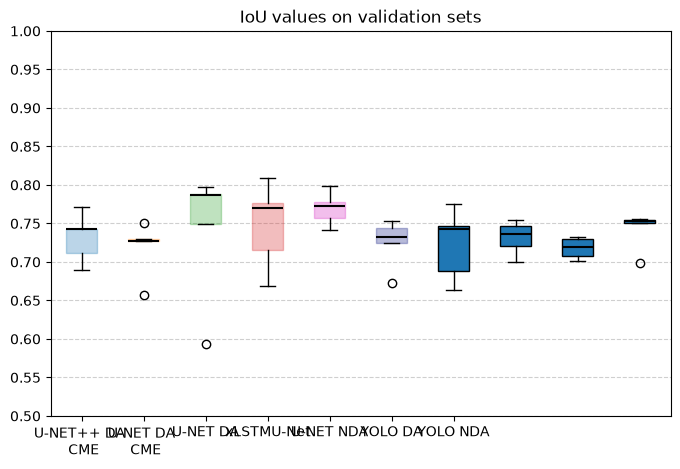

In [ ]:
data = [results_CSANET, results_XLSTM , results_UNETplusplus_CME, results_UNET_CME, results_UNET,  results_NDA_UNET, results_DA_YOLO, results_NDA_YOLO, results_UNET_no_intestin]
labels = ["U-NET++ DA \n CME", "U-NET DA \n CME" ,"U-NET DA", "xLSTMU-Net", "U-NET NDA", "YOLO DA", "YOLO NDA"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82"]  # Bleu, Orange, Vert, Rouge
limite = np.arange(0.5, 1.01, 0.05)
create_boxplot(data, labels, colors, limite_echelle=limite)

### Comparaison des moyennes

In [12]:
print(f"IoU moyen U-NEt++ avec cme: {np.mean(results_UNETplusplus_CME):.3f}")
print(f"IoU moyen U-NEt avec cme: {np.mean(results_UNET_CME):.3f}")
print(f"IoU moyen U-NEt sans cme: {np.mean(results_UNET):.3f}")
print(f"IoU moyen U-NEt sans intestin: {np.mean(results_UNET_no_intestin):.3f}")
print(f"IoU moyen U-NEt: {np.mean(results_UNET):.3f}")
print(f"IoU moyen YOLO avec data augm: {np.mean(results_DA_YOLO):.3f}")
print(f"IoU moyen YOLO sans data augm: {np.mean(results_NDA_YOLO):.3f}")

IoU moyen U-NEt++ avec cme: 0.748
IoU moyen U-NEt avec cme: 0.770
IoU moyen U-NEt sans cme: 0.725
IoU moyen U-NEt sans intestin: 0.742
IoU moyen U-NEt: 0.725
IoU moyen YOLO avec data augm: 0.731
IoU moyen YOLO sans data augm: 0.718


## Zoom sur les meilleurs modèles

In [16]:
best_results_categ1 = history_UNET_TEST
best_results_categ2 = history_UNET

In [17]:
history_CME_UNET_PLUS['fold_1'].keys()

dict_keys(['train_loss', 'val_loss', 'val_iou', 'val_iou_all', 'val_surf_diff_cm2', 'best_epoch_iou', 'best_iou_gonade', 'best_epoch_categories', 'best_epoch_diff_surf', 'best_epoch_all_iou', 'best_epoch_iou_gonade', 'fold_time_seconds'])

In [31]:
iou_gonade1 = []
all_categ1 = []
all_op1 = []
all_op_ratio1 = []
for cle, valeur in best_results_categ1.items():
    iou_gonade1.extend(best_results_categ1[cle]["best_epoch_iou_gonade"])
    all_categ1.extend(best_results_categ1[cle]["best_epoch_categories"])
    all_op1.extend(best_results_categ1[cle]["best_epoch_ops"])
    all_op_ratio1.extend(best_results_categ1[cle]["best_epoch_ops_ratio"])

iou_gonade2 = []
all_categ2 = []
all_op2 = []
all_op_ratio2 = []
for cle, valeur in best_results_categ2.items():
    iou_gonade2.extend(best_results_categ2[cle]["best_epoch_iou_gonade"])
    all_categ2.extend(best_results_categ2[cle]["best_epoch_categories"])
    all_op2.extend(best_results_categ2[cle]["best_epoch_ops"])
    all_op_ratio2.extend(best_results_categ2[cle]["best_epoch_ops_ratio"])

### Distribution des IoU pour toutes les images

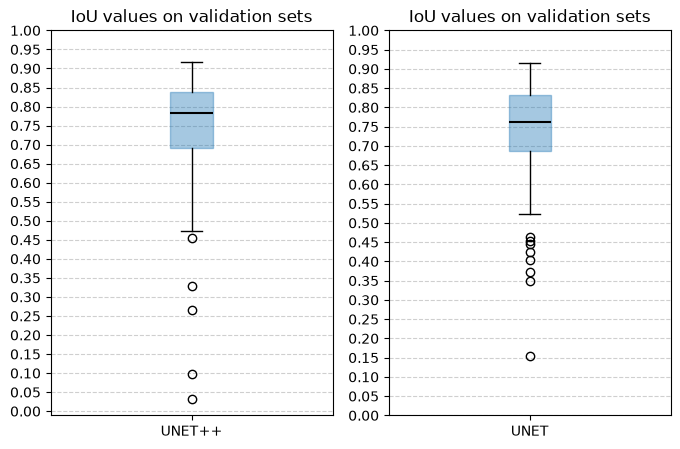

In [19]:
data1 = [iou_gonade1]
data2 = [iou_gonade2]
labels1 = ["UNET++"]
labels2 = ["UNET"]
colors = ["#1f77b4"]

plot_two_boxplots(data1, data2, labels1, labels2, colors=colors)

### Test de moyennes entre les modèles

In [20]:
print("--- Test de Welch ---")
print(st.ttest_ind(iou_gonade1, iou_gonade2, equal_var=False)) # Désactive l'hypo des variances égales

print("\n--- Test de Wilcoxon-Mann-Whitney ---")
print(st.mannwhitneyu(iou_gonade1, iou_gonade2, alternative='two-sided')) # Dans les deux sens : A > B ou A < B

--- Test de Welch ---
TtestResult(statistic=np.float64(0.32619391562483), pvalue=np.float64(0.7447742175067155), df=np.float64(137.32441684428127))

--- Test de Wilcoxon-Mann-Whitney ---
MannwhitneyuResult(statistic=np.float64(2605.0), pvalue=np.float64(0.5182538009068334))


### IoU selon les folds

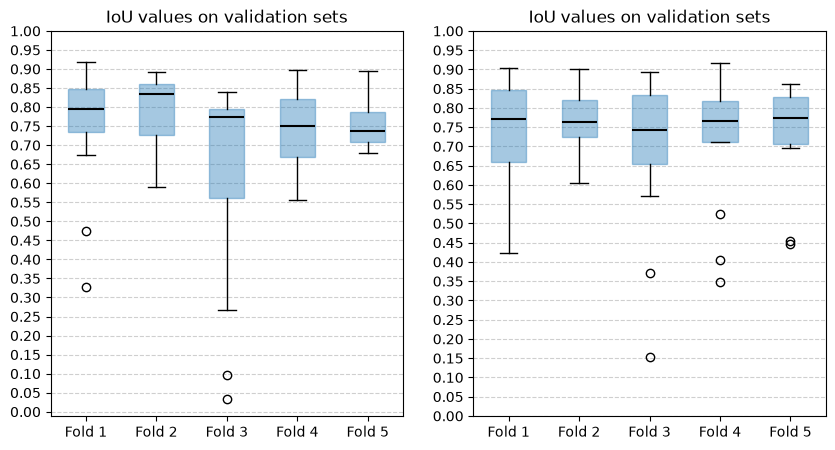

In [21]:
data1 = [best_results_categ1["fold_1"]["best_epoch_iou_gonade"], best_results_categ1["fold_2"]["best_epoch_iou_gonade"], best_results_categ1["fold_3"]["best_epoch_iou_gonade"], 
        best_results_categ1["fold_4"]["best_epoch_iou_gonade"], best_results_categ1["fold_5"]["best_epoch_iou_gonade"]]
data2 = [best_results_categ2["fold_1"]["best_epoch_iou_gonade"], best_results_categ2["fold_2"]["best_epoch_iou_gonade"], best_results_categ2["fold_3"]["best_epoch_iou_gonade"], 
        best_results_categ2["fold_4"]["best_epoch_iou_gonade"], best_results_categ2["fold_5"]["best_epoch_iou_gonade"]]
labels1 = ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]
labels2 = ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]
plt_size = (10,5)
list_colors = ["#1f77b4", "#1f77b4", "#1f77b4", "#1f77b4", "#1f77b4"]

plot_two_boxplots(data1, data2, labels1, labels2, colors=list_colors, size=plt_size)

### IoU selon les catégories

In [22]:
# Catégories 1.
indices_debut1 = [i for i, x in enumerate(all_categ1) if x == 'debut']
indices_milieu1 = [i for i, x in enumerate(all_categ1) if x == 'milieu']
indices_fin1 = [i for i, x in enumerate(all_categ1) if x == 'fin']

all_iou_debut1 = [iou_gonade1[i] for i in indices_debut1]
all_iou_milieu1 = [iou_gonade1[i] for i in indices_milieu1]
all_iou_fin1 = [iou_gonade1[i] for i in indices_fin1]

# Catégories 2.
indices_debut2 = [i for i, x in enumerate(all_categ2) if x == 'debut']
indices_milieu2 = [i for i, x in enumerate(all_categ2) if x == 'milieu']
indices_fin2 = [i for i, x in enumerate(all_categ2) if x == 'fin']

all_iou_debut2 = [iou_gonade2[i] for i in indices_debut2]
all_iou_milieu2 = [iou_gonade2[i] for i in indices_milieu2]
all_iou_fin2 = [iou_gonade2[i] for i in indices_fin2]

print("Répartition par catégories 1")
print(f"Début : {len(all_iou_debut1)}")
print(f"Milieu : {len(all_iou_milieu1)}")
print(f"Fin : {len(all_iou_fin1)}")

print("Répartition par catégories 2")
print(f"Début : {len(all_iou_debut2)}")
print(f"Milieu : {len(all_iou_milieu2)}")
print(f"Fin : {len(all_iou_fin2)}")


Répartition par catégories 1
Début : 19
Milieu : 29
Fin : 23
Répartition par catégories 2
Début : 17
Milieu : 29
Fin : 23


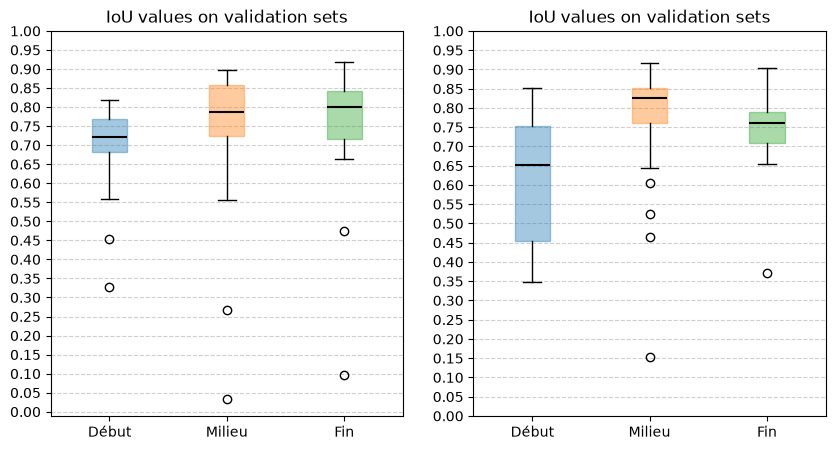

In [23]:
data1 = [all_iou_debut1, all_iou_milieu1, all_iou_fin1]
data2 = [all_iou_debut2, all_iou_milieu2, all_iou_fin2]
labels1 = ["Début", "Milieu", "Fin"]
labels2 = ["Début", "Milieu", "Fin"]
plt_size = (10,5)
list_colors = ["#1f77b4", "#ff7f0e", "#2ca02c" ]

plot_two_boxplots(data1, data2, labels1, labels2, colors=list_colors, size=plt_size)

In [24]:
print(f"Début1 : {np.mean(all_iou_debut1):.3f}")
print(f"Début2 : {np.mean(all_iou_debut2):.3f}")

print(f"Milieu1 : {np.mean(all_iou_milieu1):.3f}")
print(f"Milieu2 : {np.mean(all_iou_milieu2):.3f}")

print(f"Fin1 : {np.mean(all_iou_fin1):.3f}")
print(f"Fin2 : {np.mean(all_iou_fin2):.3f}")

Début1 : 0.687
Début2 : 0.625
Milieu1 : 0.746
Milieu2 : 0.768
Fin1 : 0.753
Fin2 : 0.742


In [25]:
print("---- Catégories 1 ---- ")
# Test de student pour vérifier si il existe une différence selon la catégorie de l'échographie
print(st.ttest_ind(all_iou_debut1, all_iou_milieu1, equal_var=True)) # Significatif à 5%
print(st.ttest_ind(all_iou_debut1, all_iou_fin1, equal_var=True)) # Signifiatif à 5%
print(st.ttest_ind(all_iou_fin1, all_iou_milieu1, equal_var=True)) # Pas de différences significatifs

print("\n ---- Catégories 2 ---- ")
# Test de student pour vérifier si il existe une différence selon la position de l'échographie
print(st.ttest_ind(all_iou_debut2, all_iou_milieu2, equal_var=True)) # Significatif à 5%
print(st.ttest_ind(all_iou_debut2, all_iou_fin2, equal_var=True)) # Significatif à 5%
print(st.ttest_ind(all_iou_fin2, all_iou_milieu2, equal_var=True)) # Pas de différences significatifs

---- Catégories 1 ---- 
TtestResult(statistic=np.float64(-1.1898231384062072), pvalue=np.float64(0.24022084240399252), df=np.float64(46.0))
TtestResult(statistic=np.float64(-1.3745941452382031), pvalue=np.float64(0.1769096667637303), df=np.float64(40.0))
TtestResult(statistic=np.float64(0.13948209339848067), pvalue=np.float64(0.8896295345558907), df=np.float64(50.0))

 ---- Catégories 2 ---- 
TtestResult(statistic=np.float64(-2.9153627859886084), pvalue=np.float64(0.005570071591917559), df=np.float64(44.0))
TtestResult(statistic=np.float64(-2.8225434075885545), pvalue=np.float64(0.007540002200980937), df=np.float64(38.0))
TtestResult(statistic=np.float64(-0.6765087989586801), pvalue=np.float64(0.5018353610916699), df=np.float64(50.0))


In [26]:
# Test de l'ANOVA
print(st.f_oneway(all_iou_debut1, all_iou_milieu1, all_iou_fin1)) #Significatif à 5%

print(st.f_oneway(all_iou_debut2, all_iou_milieu2, all_iou_fin2)) #Significatif à 5%

F_onewayResult(statistic=np.float64(0.939512198274637), pvalue=np.float64(0.39583182531844313))
F_onewayResult(statistic=np.float64(5.604485152759093), pvalue=np.float64(0.005648248231572791))


### IoU selon les positions

In [40]:
# Modèle 1 : Répartition par positions
all_iou1_op0 = [iou_gonade1[i] for i, x in enumerate(all_op1) if x == 0]
all_iou1_op1 = [iou_gonade1[i] for i, x in enumerate(all_op1) if x == 1]
all_iou1_op2 = [iou_gonade1[i] for i, x in enumerate(all_op1) if x == 2]
all_iou1_op3 = [iou_gonade1[i] for i, x in enumerate(all_op1) if x == 3]
all_iou1_op4 = [iou_gonade1[i] for i, x in enumerate(all_op1) if x == 4]
all_iou1_op5 = [iou_gonade1[i] for i, x in enumerate(all_op1) if x == 5]
all_iou1_op6 = [iou_gonade1[i] for i, x in enumerate(all_op1) if x == 6]
all_iou1_op8 = [iou_gonade1[i] for i, x in enumerate(all_op1) if x == 8]
all_iou1_op10 = [iou_gonade1[i] for i, x in enumerate(all_op1) if x == 10]

print("Répartition par positions 1")
print(f"Op 0 : {len(all_iou1_op0)}")
print(f"Op 1 : {len(all_iou1_op1)}")
print(f"Op 2 : {len(all_iou1_op2)}")
print(f"Op 3 : {len(all_iou1_op3)}")
print(f"Op 4 : {len(all_iou1_op4)}")
print(f"Op 5 : {len(all_iou1_op5)}")
print(f"Op 6 : {len(all_iou1_op6)}")
print(f"Op 8 : {len(all_iou1_op8)}")
print(f"Op 10 : {len(all_iou1_op10)}")


# Modèle 2 : Répartition par positions
all_iou2_op0 = [iou_gonade2[i] for i, x in enumerate(all_op2) if x == 0]
all_iou2_op1 = [iou_gonade2[i] for i, x in enumerate(all_op2) if x == 1]
all_iou2_op2 = [iou_gonade2[i] for i, x in enumerate(all_op2) if x == 2]
all_iou2_op3 = [iou_gonade2[i] for i, x in enumerate(all_op2) if x == 3]
all_iou2_op4 = [iou_gonade2[i] for i, x in enumerate(all_op2) if x == 4]
all_iou2_op5 = [iou_gonade2[i] for i, x in enumerate(all_op2) if x == 5]
all_iou2_op6 = [iou_gonade2[i] for i, x in enumerate(all_op2) if x == 6]
all_iou2_op8 = [iou_gonade2[i] for i, x in enumerate(all_op2) if x == 8]
all_iou2_op10 = [iou_gonade2[i] for i, x in enumerate(all_op2) if x == 10]


print("Répartition par positions 2")
print(f"Op 0 : {len(all_iou2_op0)}")
print(f"Op 1 : {len(all_iou2_op1)}")
print(f"Op 2 : {len(all_iou2_op2)}")
print(f"Op 3 : {len(all_iou2_op3)}")
print(f"Op 4 : {len(all_iou2_op4)}")
print(f"Op 5 : {len(all_iou2_op5)}")
print(f"Op 6 : {len(all_iou2_op6)}")
print(f"Op 8 : {len(all_iou2_op8)}")
print(f"Op 10 : {len(all_iou2_op10)}")

Répartition par positions 1
Op 0 : 18
Op 1 : 0
Op 2 : 21
Op 3 : 0
Op 4 : 18
Op 5 : 0
Op 6 : 10
Op 8 : 3
Op 10 : 1
Répartition par positions 2
Op 0 : 14
Op 1 : 2
Op 2 : 20
Op 3 : 2
Op 4 : 19
Op 5 : 0
Op 6 : 10
Op 8 : 2
Op 10 : 0


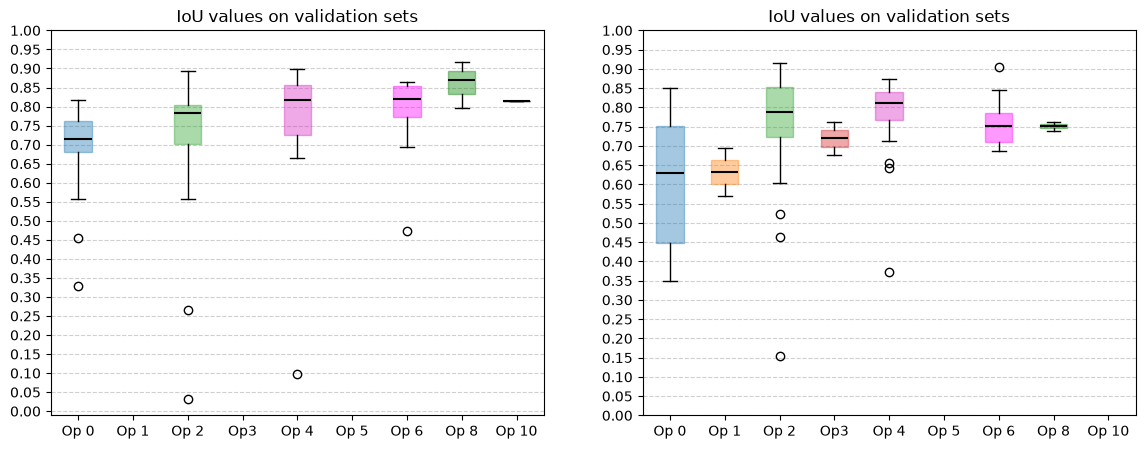

In [41]:
data1 = [all_iou1_op0, all_iou1_op1, all_iou1_op2, all_iou1_op3, all_iou1_op4, all_iou1_op5, all_iou1_op6, all_iou1_op8, all_iou1_op10]
data2 = [all_iou2_op0, all_iou2_op1, all_iou2_op2, all_iou2_op3, all_iou2_op4, all_iou2_op5, all_iou2_op6, all_iou2_op8, all_iou2_op10]
labels1 = ["Op 0", "Op 1", "Op 2", "Op3", "Op 4", "Op 5", "Op 6", "Op 8", "Op 10"]
labels2 = ["Op 0", "Op 1", "Op 2", "Op3", "Op 4", "Op 5", "Op 6", "Op 8", "Op 10"]
plt_size = (14,5)
list_colors =  ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82", "#ff00ff", "green"]  # Bleu, Orange, Vert, Rouge, rose, violet

plot_two_boxplots(data1, data2, labels1, labels2, colors=list_colors, size=plt_size)

In [36]:
# Modèle 1
op_ratio1 = [round(op, 1)*100 for op in all_op_ratio1]

all_iou1_op0 = [iou_gonade1[i] for i, x in enumerate(op_ratio1) if x == 0]
all_iou1_op1 = [iou_gonade1[i] for i, x in enumerate(op_ratio1) if x == 10]
all_iou1_op2 = [iou_gonade1[i] for i, x in enumerate(op_ratio1) if x == 20]
all_iou1_op3 = [iou_gonade1[i] for i, x in enumerate(op_ratio1) if x == 30]
all_iou1_op4 = [iou_gonade1[i] for i, x in enumerate(op_ratio1) if x == 40]
all_iou1_op5 = [iou_gonade1[i] for i, x in enumerate(op_ratio1) if x == 50]
all_iou1_op6 = [iou_gonade1[i] for i, x in enumerate(op_ratio1) if x == 60]
all_iou1_op7 = [iou_gonade1[i] for i, x in enumerate(op_ratio1) if x == 70]
all_iou1_op8 = [iou_gonade1[i] for i, x in enumerate(op_ratio1) if x == 80]
all_iou1_op9 = [iou_gonade1[i] for i, x in enumerate(op_ratio1) if x == 90]
all_iou1_op10 = [iou_gonade1[i] for i, x in enumerate(op_ratio1) if x == 100]

print("Répartition par positions 1")
print(f"Op 0 : {len(all_iou1_op0)}")
print(f"Op 10 % : {len(all_iou1_op1)}")
print(f"Op 20 % : {len(all_iou1_op2)}")
print(f"Op 30 % : {len(all_iou1_op3)}")
print(f"Op 40 % : {len(all_iou1_op4)}")
print(f"Op 50 % : {len(all_iou1_op5)}")
print(f"Op 60 % : {len(all_iou1_op6)}")
print(f"Op 70 % : {len(all_iou1_op7)}")
print(f"Op 80 % : {len(all_iou1_op8)}")
print(f"Op 90 % : {len(all_iou1_op9)}")
print(f"Op 100 % : {len(all_iou1_op10)}")

# Modèle 2
op_ratio2 = [round(op, 1)*100 for op in all_op_ratio2]

all_iou2_op0 = [iou_gonade2[i] for i, x in enumerate(op_ratio2) if x == 0]
all_iou2_op1 = [iou_gonade2[i] for i, x in enumerate(op_ratio2) if x == 10]
all_iou2_op2 = [iou_gonade2[i] for i, x in enumerate(op_ratio2) if x == 20]
all_iou2_op3 = [iou_gonade2[i] for i, x in enumerate(op_ratio2) if x == 30]
all_iou2_op4 = [iou_gonade2[i] for i, x in enumerate(op_ratio2) if x == 40]
all_iou2_op5 = [iou_gonade2[i] for i, x in enumerate(op_ratio2) if x == 50]
all_iou2_op6 = [iou_gonade2[i] for i, x in enumerate(op_ratio2) if x == 60]
all_iou2_op7 = [iou_gonade2[i] for i, x in enumerate(op_ratio2) if x == 70]
all_iou2_op8 = [iou_gonade2[i] for i, x in enumerate(op_ratio2) if x == 80]
all_iou2_op9 = [iou_gonade2[i] for i, x in enumerate(op_ratio2) if x == 90]
all_iou2_op10 = [iou_gonade2[i] for i, x in enumerate(op_ratio2) if x == 100]


print("Répartition par positions 2")
print(f"Op 0 : {len(all_iou2_op0)}")
print(f"Op 10 % : {len(all_iou2_op1)}")
print(f"Op 20 % : {len(all_iou2_op2)}")
print(f"Op 30 % : {len(all_iou2_op3)}")
print(f"Op 40 % : {len(all_iou2_op4)}")
print(f"Op 50 % : {len(all_iou2_op5)}")
print(f"Op 60 % : {len(all_iou2_op6)}")
print(f"Op 70 % : {len(all_iou2_op7)}")
print(f"Op 80 % : {len(all_iou2_op8)}")
print(f"Op 90 % : {len(all_iou2_op9)}")
print(f"Op 100 % : {len(all_iou2_op10)}")

Répartition par positions 1
Op 0 : 18
Op 10 % : 0
Op 20 % : 8
Op 30 % : 6
Op 40 % : 7
Op 50 % : 6
Op 60 % : 7
Op 70 % : 10
Op 80 % : 4
Op 90 % : 4
Op 100 % : 1
Répartition par positions 2
Op 0 : 14
Op 10 % : 1
Op 20 % : 9
Op 30 % : 6
Op 40 % : 7
Op 50 % : 7
Op 60 % : 6
Op 70 % : 11
Op 80 % : 5
Op 90 % : 2
Op 100 % : 1


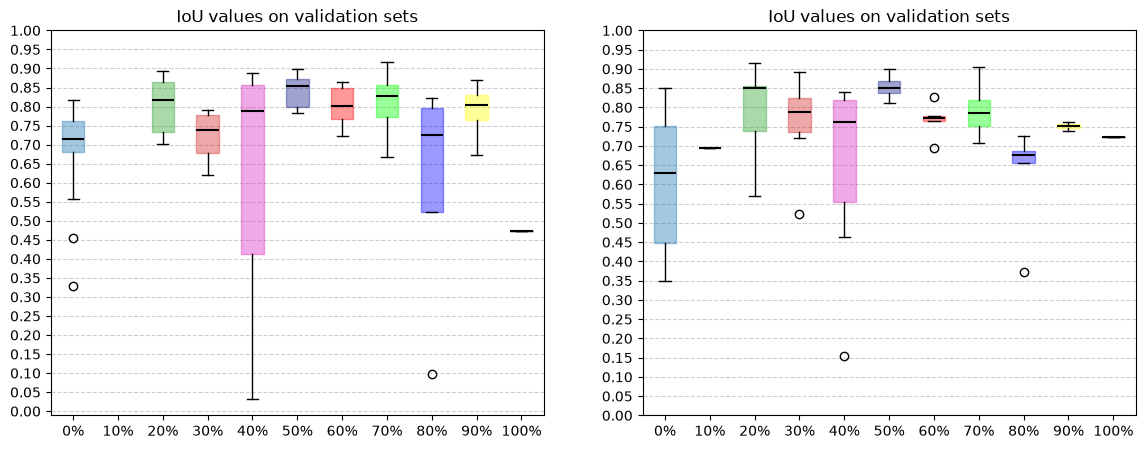

In [38]:
data1 = [all_iou1_op0, all_iou1_op1, all_iou1_op2, all_iou1_op3, all_iou1_op4, all_iou1_op5, all_iou1_op6, all_iou1_op7, all_iou1_op8, all_iou1_op9, all_iou1_op10]
data2 = [all_iou2_op0, all_iou2_op1, all_iou2_op2, all_iou2_op3, all_iou2_op4, all_iou2_op5, all_iou2_op6, all_iou2_op7, all_iou2_op8, all_iou2_op9, all_iou2_op10]
labels1 = ["0%", "10%", "20%", "30%", "40%", "50%", "60%", "70%", "80%", "90%", "100%"]
labels2 = ["0%", "10%", "20%", "30%", "40%", "50%", "60%", "70%", "80%", "90%", "100%"]
plt_size = (14,5)
list_colors =  ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82", "#ff0000", "#00ff00", "#0000ff", "#ffff00"]  # Bleu, Orange, Vert, Rouge, rose, violet

plot_two_boxplots(data1, data2, labels1, labels2, colors=list_colors, size=plt_size)

## Afficher les outliers

In [ ]:
# Récupère les images avec un IoU inférieur à 0.55
indices = [i for i,x in enumerate(iou_gonade1) if x < 0.55]

[0, 3, 30, 38, 42, 43]

# Résultats sur l'échantillon de test

In [40]:
# U-Net avec Data Augmentation, BCE + Dice loss
with open('../U-NET/saves/categories_test.pkl', 'rb') as f:
    results_categ_test = pickle.load(f)

In [62]:
all_iou_test = [float(res) for res in results_categ_test["all_iou"]]
all_categ_test = results_categ_test["categories"]

In [42]:
indices_debut_test = [i for i, x in enumerate(all_categ_test) if x == 'debut']
indices_milieu_test = [i for i, x in enumerate(all_categ_test) if x == 'milieu']
indices_fin_test = [i for i, x in enumerate(all_categ_test) if x == 'fin']

all_iou_debut_test = [float(all_iou_test[i]) for i in indices_debut_test]
all_iou_milieu_test = [float(all_iou_test[i]) for i in indices_milieu_test]
all_iou_fin_test = [float(all_iou_test[i]) for i in indices_fin_test]

print("Répartition par catégories")
print(f"Début : {len(all_iou_debut_test)}")
print(f"Milieu : {len(all_iou_milieu_test)}")
print(f"Fin : {len(all_iou_fin_test)}")

Répartition par catégories
Début : 3
Milieu : 6
Fin : 4


### Distribution des IoU

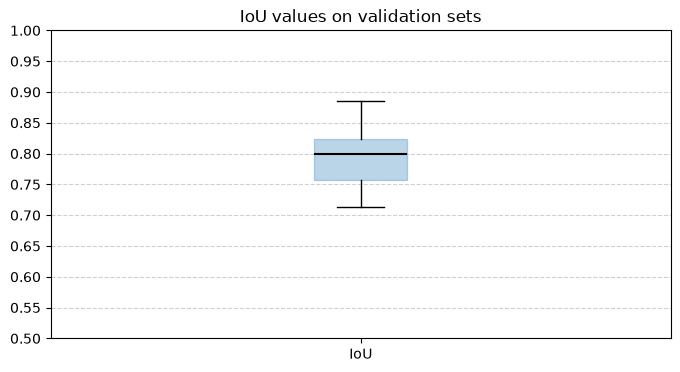

In [65]:
data = [all_iou_test]
labels = ["IoU"]
colors = ["#1f77b4"]  # Bleu, Orange, Vert, Rouge, rose, violet
size = (8,4)
create_boxplot(data, labels, colors, size=size, limite_echelle=np.arange(0.5, 1.01, 0.05))

### Boxplots par catégories

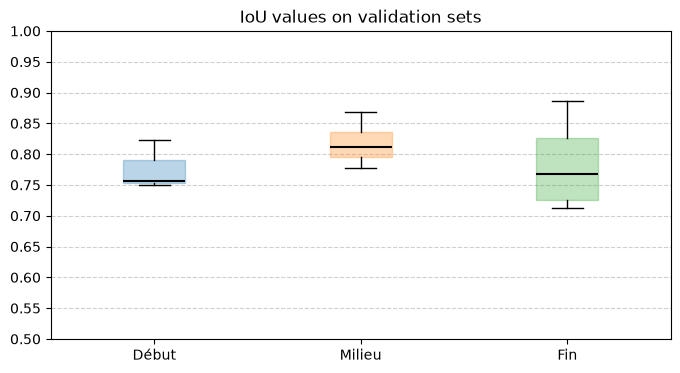

In [52]:
data = [all_iou_debut_test, all_iou_milieu_test, all_iou_fin_test]
labels = ["Début", "Milieu", "Fin"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c" ]  # Bleu, Orange, Vert, Rouge, rose, violet
size = (8,4)
create_boxplot(data, labels, colors, size=size, limite_echelle=np.arange(0.5, 1.01, 0.05))

In [67]:
# Test de l'ANOVA
print(st.f_oneway(all_iou_debut_test, all_iou_milieu_test, all_iou_fin_test)) # Pas de différences significatives de la moyenne

# Test de Levene pour vérifier l'hypothèse des variances égales
print(st.levene(all_iou_debut_test, all_iou_milieu_test, all_iou_fin_test))

F_onewayResult(statistic=np.float64(0.7752877770136098), pvalue=np.float64(0.4863869048687699))
LeveneResult(statistic=np.float64(2.206851919887238), pvalue=np.float64(0.16073928362260426))
